### 1: Imports

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))

### 2: Load Data

In [15]:
data_path = os.path.join(BASE_DIR, 'processed_data.csv')
df = pd.read_csv(data_path)

feature_cols = [col for col in df.columns if col not in ['pain_level', 'person_id']]
input_size = len(feature_cols)
people_ids = df['person_id'].unique()

print(f"Total events: {len(df)}")
print(f"People: {people_ids}")
print(f"Features: {input_size}")
print(f"\nClass balance:")
print(df.groupby(['person_id', 'pain_level']).size().unstack(fill_value=0))

Total events: 64
People: [0. 1. 2. 3.]
Features: 13

Class balance:
pain_level  0.0  1.0  2.0  3.0
person_id                     
0.0           4    4    4    4
1.0           4    4    4    4
2.0           4    4    4    4
3.0           4    4    4    4


In [ ]:
def augment_data(df, feature_cols, n_copies=5, noise_std=0.05):
    augmented = [df.copy()]
    
    for _ in range(n_copies):
        copy = df.copy()
        noise = np.random.normal(0, noise_std, size=copy[feature_cols].shape)
        copy[feature_cols] = copy[feature_cols] + noise
        augmented.append(copy)
    
    result = pd.concat(augmented, ignore_index=True)
    return result

# augment training data only - test data stays clean
# we apply this inside the LOOCV loop, not here
print(f"Original events: {len(df)}")
print(f"After augmentation per fold: ~{len(df) * 6} training samples")

### 3 torch dataset

In [16]:
class PainDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        labels = y.values.copy()
        if labels.min() == 1:
            labels = labels - 1
        self.y = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        features = self.X[idx]
        if self.augment:
            noise = torch.randn_like(features) * 0.01
            features = features + noise
        return features, self.y[idx]

### 4: model

In [17]:
class PainTrackerMLP(nn.Module):
    def __init__(self, input_size, num_classes=4):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.1) 
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.1)
        self.output_layer = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        return self.output_layer(x)

### 5: hyperparams

In [18]:
EPOCHS = 150       
BATCH_SIZE = 16    
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 4

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score

logo = LeaveOneGroupOut()
X = df[feature_cols].values
y = df['pain_level'].values
groups = df['person_id'].values

svm_scores = []
svm_true = []
svm_pred = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
     # augment train fold only
    train_temp = pd.DataFrame(X_train, columns=feature_cols)
    train_temp['pain_level'] = y_train
    train_temp['person_id'] = groups[train_idx]
    train_temp = augment_data(train_temp, feature_cols, n_copies=5, noise_std=0.05)
    X_train = train_temp[feature_cols].values
    y_train = train_temp['pain_level'].values
    
    # scale inside fold
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    svm = SVC(kernel='rbf', C=5, gamma='scale')
    svm.fit(X_train, y_train)
    preds = svm.predict(X_test)
    
    acc = accuracy_score(y_test, preds) * 100
    svm_scores.append(acc)
    svm_true.extend(y_test)
    svm_pred.extend(preds)
    print(f"Person accuracy: {acc:.2f}%")

print(f"\nSVM LOOCV Accuracy: {np.mean(svm_scores):.2f}%")

Person accuracy: 12.50%
Person accuracy: 25.00%
Person accuracy: 37.50%
Person accuracy: 18.75%

SVM LOOCV Accuracy: 23.44%


### 6: LOOCV (leave one out cross validation) loop

--- Fold: Testing on Person 0.0 ---


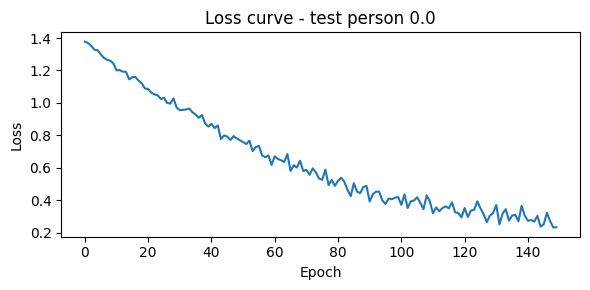

Person 0.0 accuracy: 31.25%

--- Fold: Testing on Person 1.0 ---


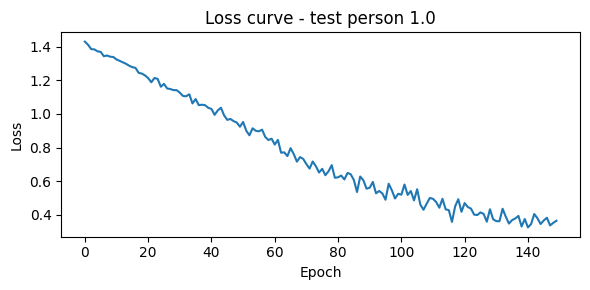

Person 1.0 accuracy: 18.75%

--- Fold: Testing on Person 2.0 ---


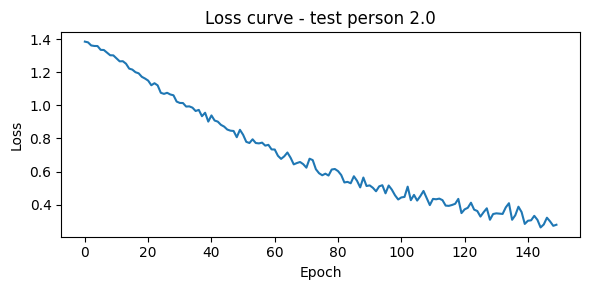

Person 2.0 accuracy: 31.25%

--- Fold: Testing on Person 3.0 ---


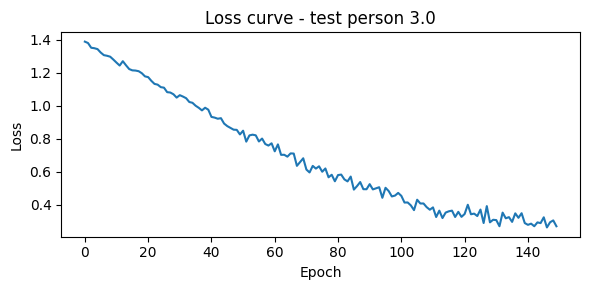

Person 3.0 accuracy: 12.50%

Average LOOCV Accuracy: 23.44%


In [ ]:
all_accuracies = []
all_true = []
all_pred = []

for test_person in people_ids:
    print(f"--- Fold: Testing on Person {test_person} ---")
    
    train_df = df[df['person_id'] != test_person]
    test_df  = df[df['person_id'] == test_person]

    # augment train fold only
    train_df = augment_data(train_df, feature_cols, n_copies=5, noise_std=0.05)
    train_df = train_df.reset_index(drop=True)
    
    # fit scaler on train fold only - no data leakage
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols])
    X_test  = scaler.transform(test_df[feature_cols])
    
    
    X_train_df = pd.DataFrame(X_train, columns=feature_cols)
    X_test_df  = pd.DataFrame(X_test,  columns=feature_cols)
    
    train_loader = DataLoader(
        PainDataset(X_train_df, train_df['pain_level'].reset_index(drop=True), augment=True),
        batch_size=BATCH_SIZE, shuffle=True
    )
    test_loader = DataLoader(
        PainDataset(X_test_df, test_df['pain_level'].reset_index(drop=True), augment=False),
        batch_size=BATCH_SIZE, shuffle=False
    )
    
    model = PainTrackerMLP(input_size=input_size, num_classes=NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    loss_history = []
    
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        scheduler.step(avg_loss)
    
    # plot loss curve for this fold
    plt.figure(figsize=(6,3))
    plt.plot(loss_history)
    plt.title(f"Loss curve - test person {test_person}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()
    
    model.eval()
    correct, total = 0, 0
    fold_true, fold_pred = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            fold_true.extend(batch_y.tolist())
            fold_pred.extend(predicted.tolist())
    
    accuracy = 100 * correct / total if total > 0 else 0
    all_accuracies.append(accuracy)
    all_true.extend(fold_true)
    all_pred.extend(fold_pred)
    print(f"Person {test_person} accuracy: {accuracy:.2f}%\n")

print("=========================================")
print(f"Average LOOCV Accuracy: {np.mean(all_accuracies):.2f}%")
print("=========================================")

### 7: Confusion Matrix

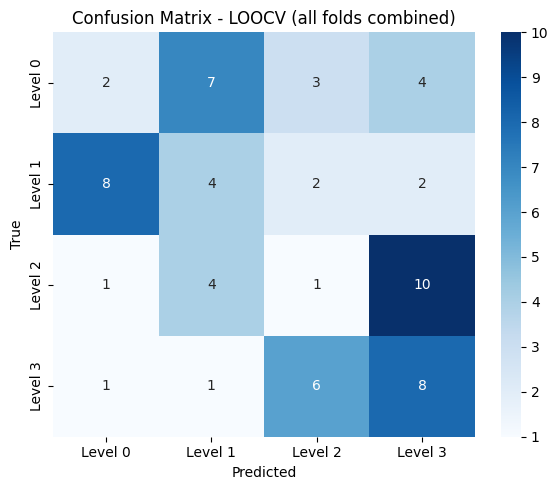

In [11]:
cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Level {i}' for i in range(NUM_CLASSES)],
            yticklabels=[f'Level {i}' for i in range(NUM_CLASSES)])
plt.title("Confusion Matrix - LOOCV (all folds combined)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### 8: train final base model on ALL data, then save

In [12]:
# scaler fit on all data this time - this is the production scaler
final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(df[feature_cols])
X_all_df = pd.DataFrame(X_all, columns=feature_cols)

final_loader = DataLoader(
    PainDataset(X_all_df, df['pain_level'].reset_index(drop=True), augment=True),
    batch_size=BATCH_SIZE, shuffle=True
)

final_model = PainTrackerMLP(input_size=input_size, num_classes=NUM_CLASSES)
final_optimizer = optim.Adam(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
final_criterion = nn.CrossEntropyLoss()

final_model.train()
for epoch in range(EPOCHS):
    for batch_X, batch_y in final_loader:
        final_optimizer.zero_grad()
        outputs = final_model(batch_X)
        loss = final_criterion(outputs, batch_y)
        loss.backward()
        final_optimizer.step()

# save model and scaler
torch.save(final_model.state_dict(), os.path.join(BASE_DIR, 'base_model.pth'))
joblib.dump(final_scaler, os.path.join(BASE_DIR, 'scaler.pkl'))

print("base_model.pth and scaler.pkl saved.")
print("These two files are what gets shipped with the phone app.")


base_model.pth and scaler.pkl saved.
These two files are what gets shipped with the phone app.
